In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
%pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
from ucimlrepo import fetch_ucirepo

iranian_churn = fetch_ucirepo(id=563)

X = iranian_churn.data.features
y = iranian_churn.data.targets

df = pd.concat([X, y], axis=1)

df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [9]:
df.shape

(3150, 14)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Call  Failure            3150 non-null   int64  
 1   Complains                3150 non-null   int64  
 2   Subscription  Length     3150 non-null   int64  
 3   Charge  Amount           3150 non-null   int64  
 4   Seconds of Use           3150 non-null   int64  
 5   Frequency of use         3150 non-null   int64  
 6   Frequency of SMS         3150 non-null   int64  
 7   Distinct Called Numbers  3150 non-null   int64  
 8   Age Group                3150 non-null   int64  
 9   Tariff Plan              3150 non-null   int64  
 10  Status                   3150 non-null   int64  
 11  Age                      3150 non-null   int64  
 12  Customer Value           3150 non-null   float64
 13  Churn                    3150 non-null   int64  
dtypes: float64(1), int64(13)
memory usa

In [11]:
df.isnull().sum()

Call  Failure              0
Complains                  0
Subscription  Length       0
Charge  Amount             0
Seconds of Use             0
Frequency of use           0
Frequency of SMS           0
Distinct Called Numbers    0
Age Group                  0
Tariff Plan                0
Status                     0
Age                        0
Customer Value             0
Churn                      0
dtype: int64

In [12]:
df.describe()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
count,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000
mean,7.627937,0.076508,32.541905,0.942857,4472.459683,69.460635,73.174921,23.509841,2.826032,1.077778,1.248254,30.998413,470.972916,0.157143
std,7.263886,0.265851,8.573482,1.521072,4197.908687,57.413308,112.237560,17.217337,0.892555,0.267864,0.432069,8.831095,517.015433,0.363993
min,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,15.000000,0.000000,0.000000
25%,1.000000,0.000000,30.000000,0.000000,1391.250000,27.000000,6.000000,10.000000,2.000000,1.000000,1.000000,25.000000,113.801250,0.000000
50%,6.000000,0.000000,35.000000,0.000000,2990.000000,54.000000,21.000000,21.000000,3.000000,1.000000,1.000000,30.000000,228.480000,0.000000
75%,12.000000,0.000000,38.000000,1.000000,6478.250000,95.000000,87.000000,34.000000,3.000000,1.000000,1.000000,30.000000,788.388750,0.000000
max,36.000000,1.000000,47.000000,10.000000,17090.000000,255.000000,522.000000,97.000000,5.000000,2.000000,2.000000,55.000000,2165.280000,1.000000


In [13]:
df['Churn'].value_counts()

Churn
0    2655
1     495
Name: count, dtype: int64

In [14]:
df['Churn'].value_counts(normalize=True) * 100

Churn
0    84.285714
1    15.714286
Name: proportion, dtype: float64

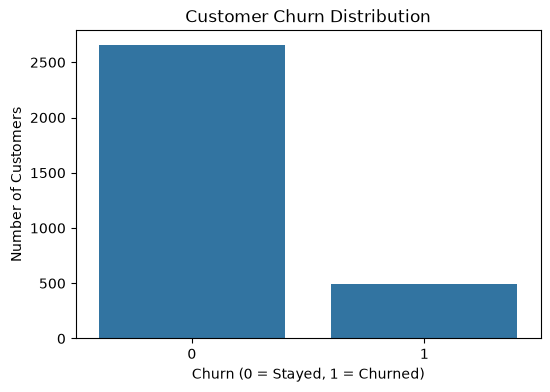

In [15]:
plt.figure(figsize=(6, 4))

sns.countplot(x='Churn', data=df)

plt.title('Customer Churn Distribution')
plt.xlabel('Churn (0 = Stayed, 1 = Churned)')
plt.ylabel('Number of Customers')

plt.show()

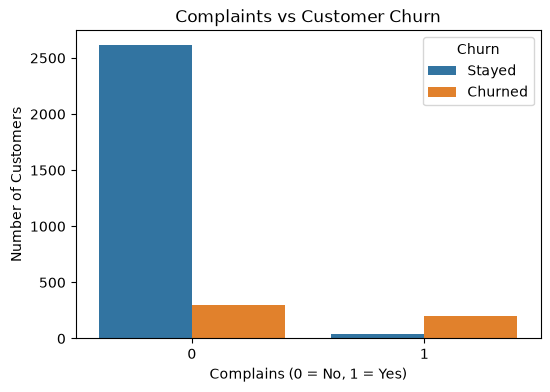

In [16]:
plt.figure(figsize=(6, 4))

sns.countplot(x='Complains', hue='Churn', data=df)

plt.title('Complaints vs Customer Churn')
plt.xlabel('Complains (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')
plt.legend(title='Churn', labels=['Stayed', 'Churned'])

plt.show()

In [18]:
df.columns.tolist()

['Call  Failure',
 'Complains',
 'Subscription  Length',
 'Charge  Amount',
 'Seconds of Use',
 'Frequency of use',
 'Frequency of SMS',
 'Distinct Called Numbers',
 'Age Group',
 'Tariff Plan',
 'Status',
 'Age',
 'Customer Value',
 'Churn']

In [19]:
df.columns = df.columns.str.replace(r'\s+', ' ', regex=True).str.strip()

df.columns.tolist()

['Call Failure',
 'Complains',
 'Subscription Length',
 'Charge Amount',
 'Seconds of Use',
 'Frequency of use',
 'Frequency of SMS',
 'Distinct Called Numbers',
 'Age Group',
 'Tariff Plan',
 'Status',
 'Age',
 'Customer Value',
 'Churn']

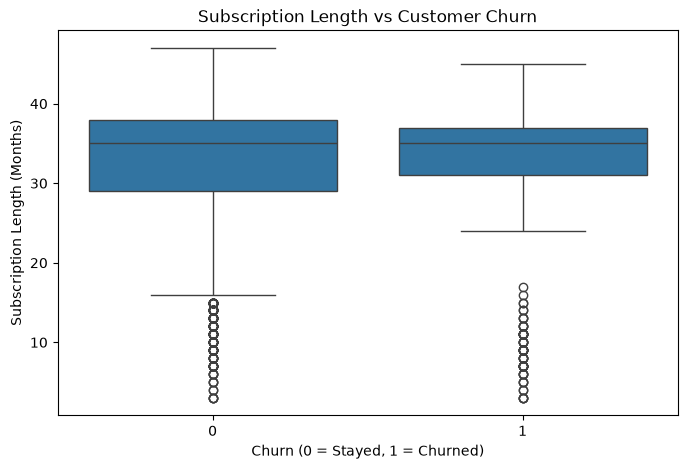

In [20]:
plt.figure(figsize=(8, 5))

sns.boxplot(x='Churn', y='Subscription Length', data=df)

plt.title('Subscription Length vs Customer Churn')
plt.xlabel('Churn (0 = Stayed, 1 = Churned)')
plt.ylabel('Subscription Length (Months)')

plt.show()

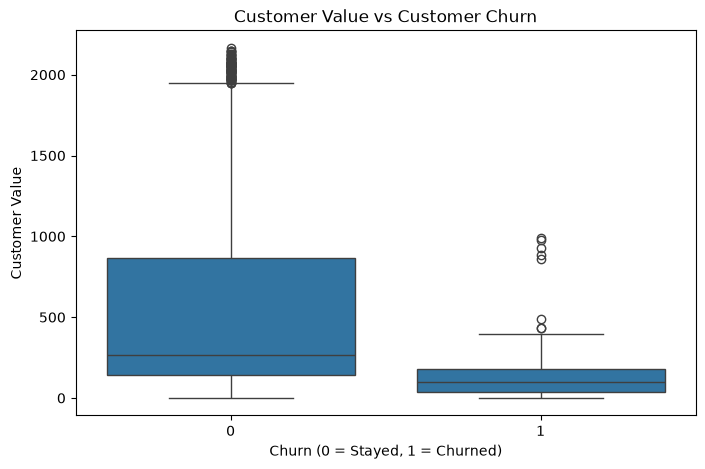

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(x='Churn', y='Customer Value', data=df)

plt.title('Customer Value vs Customer Churn')
plt.xlabel('Churn (0 = Stayed, 1 = Churned)')
plt.ylabel('Customer Value')

plt.show()

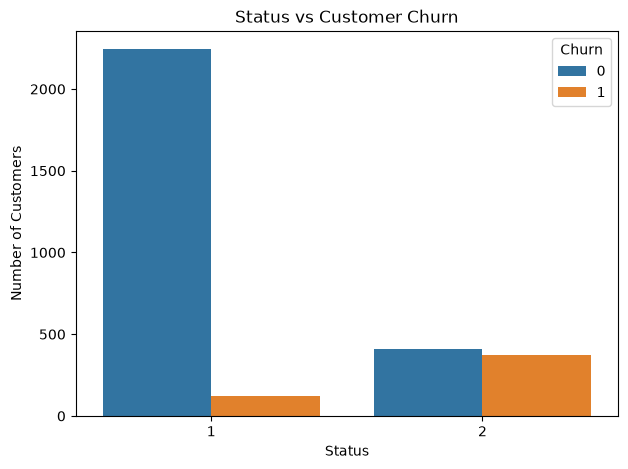

In [23]:
plt.figure(figsize=(7, 5))

sns.countplot(x='Status', hue='Churn', data=df)

plt.title('Status vs Customer Churn')
plt.xlabel('Status')
plt.ylabel('Number of Customers')

plt.show()

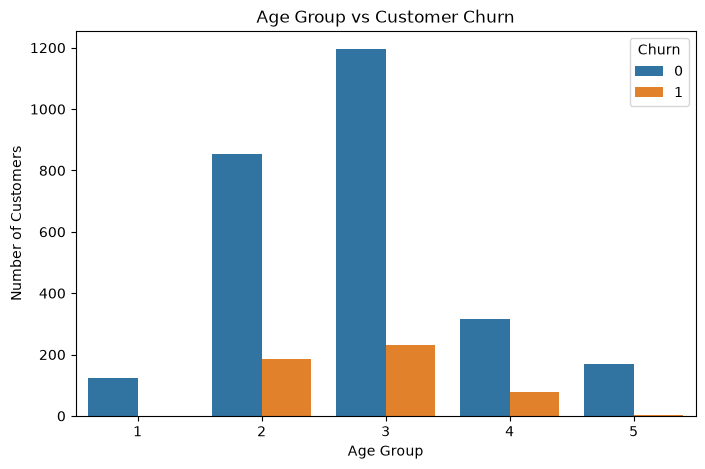

In [24]:
plt.figure(figsize=(8, 5))

sns.countplot(x='Age Group', hue='Churn', data=df)

plt.title('Age Group vs Customer Churn')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')

plt.show()

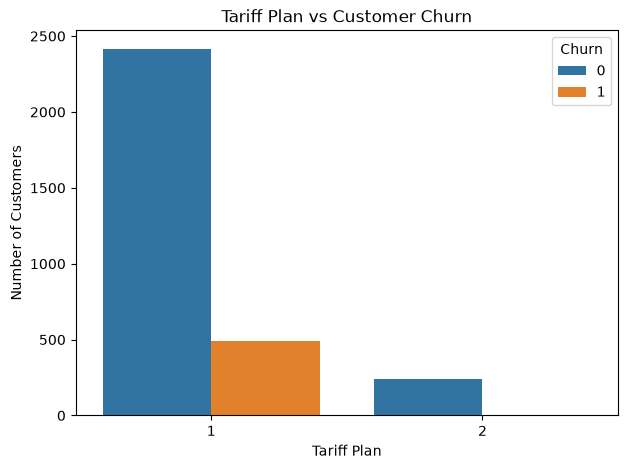

In [25]:
plt.figure(figsize=(7, 5))

sns.countplot(x='Tariff Plan', hue='Churn', data=df)

plt.title('Tariff Plan vs Customer Churn')
plt.xlabel('Tariff Plan')
plt.ylabel('Number of Customers')

plt.show()

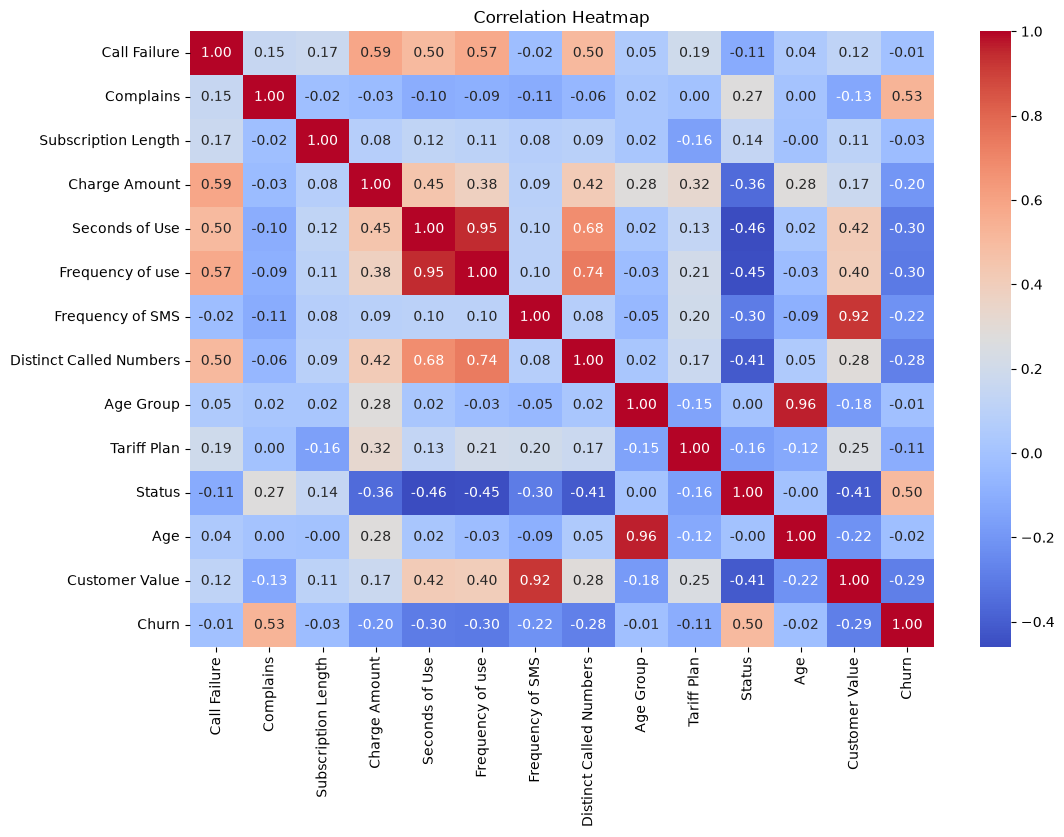

In [26]:
plt.figure(figsize=(12, 8))

correlation = df.corr(numeric_only=True)

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

In [27]:
X = df.drop('Churn', axis=1)
y = df['Churn']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (3150, 13)
Target shape: (3150,)


In [29]:
%pip install scikit-learn

  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/72/8d/27c054166bac671770d1ea0ef7716134fe8119c0df224a58c89fd735a61c/scikit_learn-1.9.1-cp312-cp312-win_amd64.whl.metadata
  Using cached scikit_learn-1.9.1-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
  Obtaining dependency information for scipy>=1.10.0 from https://files.pythonhosted.org/packages/39/e7/979fd14e75008623df31ba70d6bb144700f68feadcea042021c06a05bf82/scipy-1.18.1-cp312-cp312-win_amd64.whl.metadata
  Using cached scipy-1.18.1-cp312-cp312-win_amd64.whl.metadata (61 kB)
  Obtaining dependency information for joblib>=1.4.0 from https://files.pythonhosted.org/packages/18/53/84099323c2ec4be98d935f63c033ac4151ee83836ca1050ede3b3aadf155/joblib-1.6.0-py3-none-any.whl.metadata
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Obtaining dependency information for narwhals>=2.0.1 from https://files.pythonhosted.org/packages/40/b5/1b84b2c784db76d69442334bc8b8748c840f13ca53be086


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
from sklearn.model_selection import train_test_split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2520, 13)
Testing data: (630, 13)


In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data scaled:", X_train_scaled.shape)
print("Testing data scaled:", X_test_scaled.shape)

Training data scaled: (2520, 13)
Testing data scaled: (630, 13)


In [34]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(random_state=42)

logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred_logistic)
precision = precision_score(y_test, y_pred_logistic)
recall = recall_score(y_test, y_pred_logistic)
f1 = f1_score(y_test, y_pred_logistic)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Logistic Regression Results
---------------------------
Accuracy : 0.8968
Precision: 0.84
Recall   : 0.4242
F1 Score : 0.5638


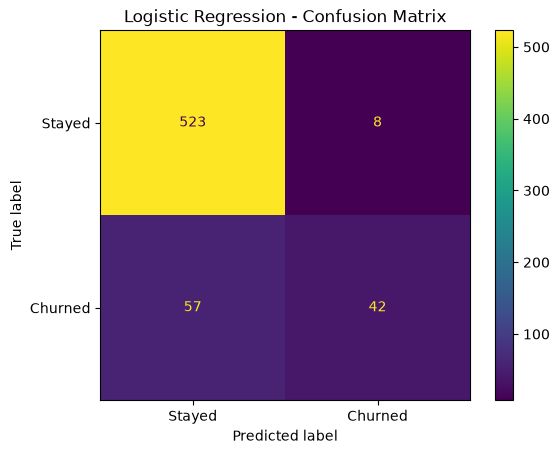

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_logistic)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Stayed', 'Churned']
)

disp.plot()

plt.title('Logistic Regression - Confusion Matrix')
plt.show()

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall   :", round(recall_rf, 4))
print("F1 Score :", round(f1_rf, 4))

Random Forest Results
---------------------
Accuracy : 0.9651
Precision: 0.9231
Recall   : 0.8485
F1 Score : 0.8842


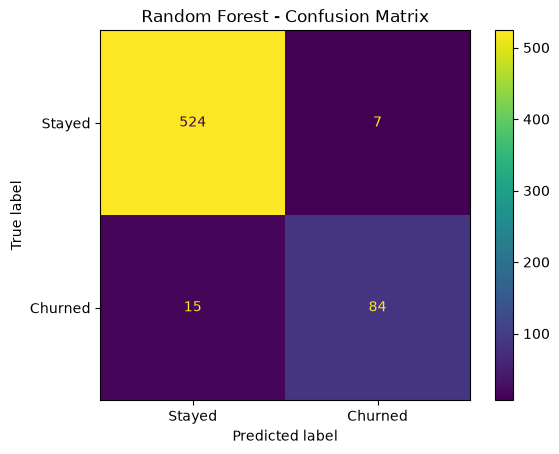

In [39]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=['Stayed', 'Churned']
)

disp.plot()

plt.title('Random Forest - Confusion Matrix')
plt.show()

In [41]:
%pip install xgboost

  Obtaining dependency information for xgboost from https://files.pythonhosted.org/packages/2f/3c/925394671f6a1668e2a71886de66e80be694eaf37f615cec74eefaf43107/xgboost-3.4.1-py3-none-win_amd64.whl.metadata
  Using cached xgboost-3.4.1-py3-none-win_amd64.whl.metadata (2.0 kB)
Using cached xgboost-3.4.1-py3-none-win_amd64.whl (48.9 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print("XGBoost Results")
print("----------------")
print("Accuracy :", round(accuracy_xgb, 4))
print("Precision:", round(precision_xgb, 4))
print("Recall   :", round(recall_xgb, 4))
print("F1 Score :", round(f1_xgb, 4))

XGBoost Results
----------------
Accuracy : 0.9651
Precision: 0.8889
Recall   : 0.8889
F1 Score : 0.8889


In [44]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [accuracy, accuracy_rf, accuracy_xgb],
    'Precision': [precision, precision_rf, precision_xgb],
    'Recall': [recall, recall_rf, recall_xgb],
    'F1 Score': [f1, f1_rf, f1_xgb]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.896825,0.840000,0.424242,0.563758
1,Random Forest,0.965079,0.923077,0.848485,0.884211
2,XGBoost,0.965079,0.888889,0.888889,0.888889


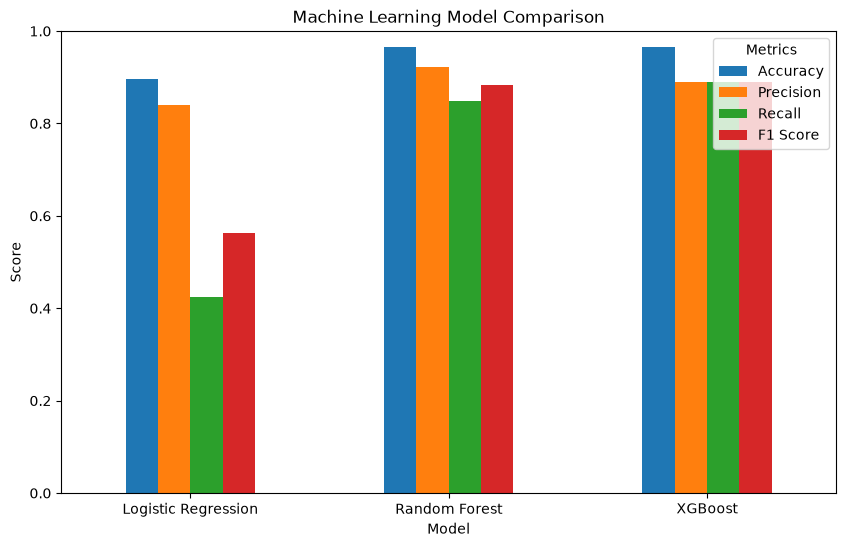

In [45]:
results.set_index('Model').plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Machine Learning Model Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.legend(title='Metrics')
plt.show()

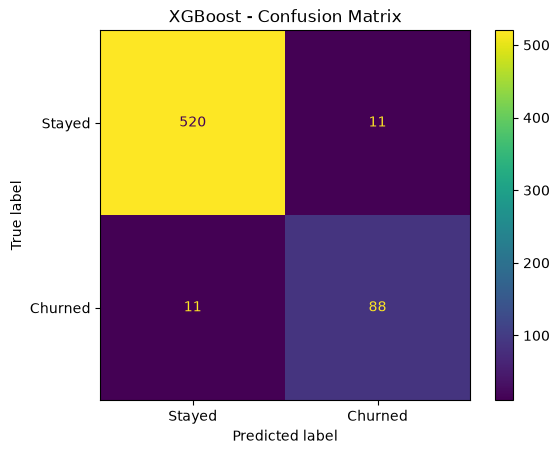

In [46]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=['Stayed', 'Churned']
)

disp.plot()

plt.title('XGBoost - Confusion Matrix')
plt.show()

In [48]:
importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

Status                     0.527323
Complains                  0.213700
Seconds of Use             0.050657
Subscription Length        0.040269
Distinct Called Numbers    0.037077
Call Failure               0.027179
Frequency of use           0.024972
Customer Value             0.024211
Age Group                  0.023492
Frequency of SMS           0.020415
Charge Amount              0.010703
Tariff Plan                0.000000
Age                        0.000000
dtype: float32


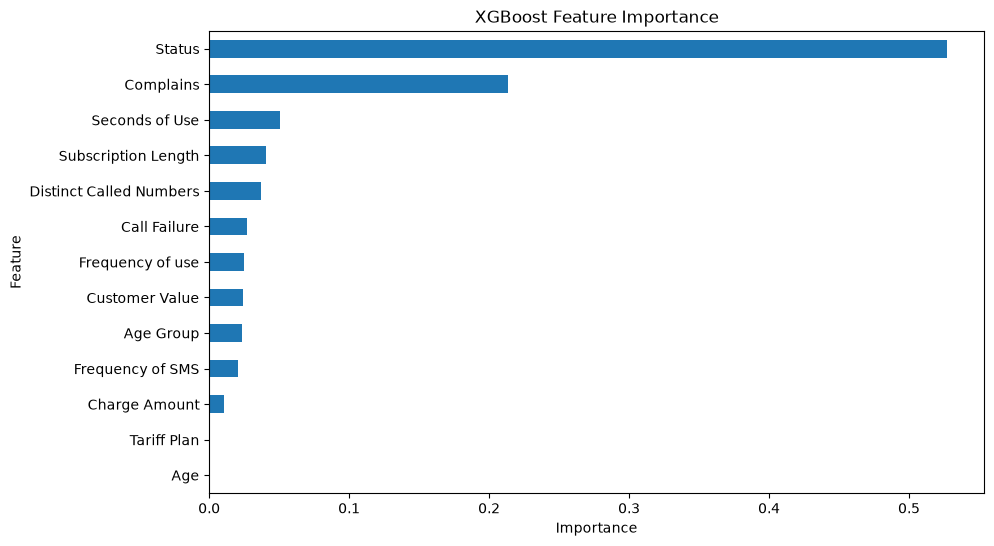

In [49]:
plt.figure(figsize=(10, 6))

importance.sort_values().plot(kind='barh')

plt.title('XGBoost Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

In [50]:
from sklearn.metrics import roc_auc_score

auc_logistic = roc_auc_score(
    y_test,
    logistic_model.predict_proba(X_test_scaled)[:, 1]
)

auc_rf = roc_auc_score(
    y_test,
    rf_model.predict_proba(X_test)[:, 1]
)

auc_xgb = roc_auc_score(
    y_test,
    xgb_model.predict_proba(X_test)[:, 1]
)

print("ROC-AUC Scores")
print("----------------")
print("Logistic Regression:", round(auc_logistic, 4))
print("Random Forest      :", round(auc_rf, 4))
print("XGBoost             :", round(auc_xgb, 4))

ROC-AUC Scores
----------------
Logistic Regression: 0.9208
Random Forest      : 0.9877
XGBoost             : 0.9897


In [53]:
sample_customer = X_test.iloc[[0]]

prediction = xgb_model.predict(sample_customer)[0]
probability = xgb_model.predict_proba(sample_customer)[0][1]

print("Predicted Churn:", prediction)
print("Churn Probability:", round(probability * 100, 2), "%")

Predicted Churn: 0
Churn Probability: 13.3 %


In [52]:
from sklearn.metrics import classification_report

print("XGBoost Classification Report")
print("--------------------------------")
print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=['Stayed', 'Churned']
))

XGBoost Classification Report
--------------------------------
              precision    recall  f1-score   support

      Stayed       0.98      0.98      0.98       531
     Churned       0.89      0.89      0.89        99

    accuracy                           0.97       630
   macro avg       0.93      0.93      0.93       630
weighted avg       0.97      0.97      0.97       630



# Iranian Customer Churn Prediction

## Project Objective

This project predicts whether a telecom customer is likely to churn (leave the service) using machine learning.

### Dataset
Iranian Churn Dataset — UCI Machine Learning Repository

### Models Used
- Logistic Regression
- Random Forest
- XGBoost

### Best Model
XGBoost

### Best Results
- Accuracy: 96.51%
- Precision: 88.89%
- Recall: 88.89%
- F1 Score: 88.89%
- ROC-AUC: 98.97%

# Final Conclusion

The project successfully predicts customer churn using machine learning.

Among the three tested models, XGBoost achieved the best overall performance.

### Final Performance

- Accuracy: 96.51%
- Precision: 88.89%
- Recall: 88.89%
- F1 Score: 88.89%
- ROC-AUC: 98.97%

The model can help telecom companies identify customers who are at high risk of leaving and take retention actions before they churn.

## Future Improvements

- Build a web application for real-time churn prediction.
- Add customer risk levels such as Low, Medium, and High.
- Provide personalized retention recommendations.
- Deploy the model using Flask or FastAPI.

In [54]:
df.to_csv("iranian_churn_dataset.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!
